# since KNN is all about distance and numbers Scaling is the most important feature here

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
columns_to_drop = ['target', 'FT%', 'league_ft_pct', 'Player', 'Rk', 'Awards', 'Team', 'Pos', 'Season']
x = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

x = x.select_dtypes(include=[np.number])
y = df["target"]
print("Columns being used for training:", x.columns.tolist())

Columns being used for training: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# n_neighbors=5 means it will look at the 5 most statistically similar players to make its guess
knn_model = KNeighborsClassifier(n_neighbors=5)

In [7]:
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
y_pred = knn_model.predict(X_test_scaled)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy: 71.48%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      2270
           1       0.71      0.67      0.69      1986

    accuracy                           0.71      4256
   macro avg       0.71      0.71      0.71      4256
weighted avg       0.71      0.71      0.71      4256



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)

<Axes: >

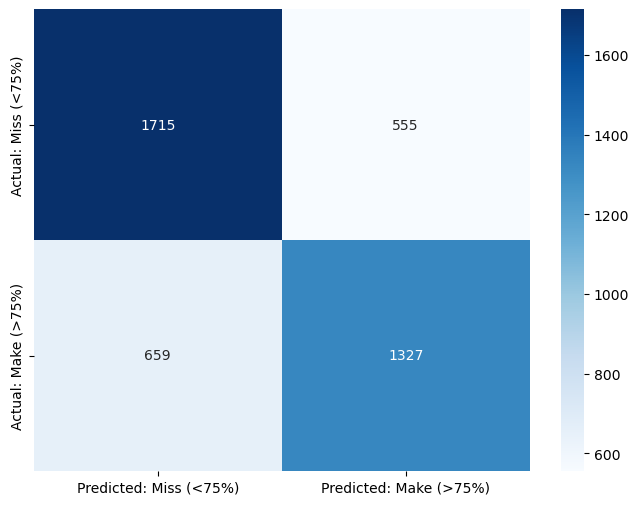

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Miss (<75%)', 'Predicted: Make (>75%)'], 
            yticklabels=['Actual: Miss (<75%)', 'Actual: Make (>75%)'])

In [13]:
plt.savefig('knn_confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [14]:
joblib.dump(knn_model, "knn.pkl")
joblib.dump(scaler, "knn_scaler.pkl")

['knn_scaler.pkl']